# Diamonds価格分析 — v020-exp-05

## 分析計画
1. 指定Kaggle公開データをSDKで検索・ファイル一覧確認・取得し、取得日時とSHA-256を固定する。API失敗時のみ指定公開CSVへ移行する。
2. 列定義・単位・母集団の確からしさをmanifestに記録し、欠損、重複、寸法ゼロ、不合理な寸法・比率を検査する。
3. 価格分布、重量と価格、品質別の未調整価格を図示する。重量はcarat（1 ct=0.2 g）、寸法はmm、価格はUSDとデータ辞書で確認する。時点・取引過程・代表性は不明として扱う。
4. 同じ固定holdoutで重量単独→品質追加→比率追加の対数価格モデルを比較し、品質の交絡と非線形性を検討する。予測性能は観察的説明力であり因果効果ではない。
5. 初回結果を読み直し、実質的な未解決点だけ自然言語の追加依頼として最大3回検討する。外れ値・重複・モデル仕様への感度を調べる。
6. 全コードセルを上から再実行し、図表visual_audit=Trueと根拠リンク、ライフサイクルを監査する。

## 再実行方針・実行経路
分析/APIコードはJupyter MCPのセル実行のみ。取得済みCSVはSHA-256照合で再利用し、データが変化しない再実行を優先する。再取得する場合のみdata/diamonds.csvとprovenance.jsonを明示的に退避する。トークンは表示・保存しない。Notebook構成/根拠の書込みはproject_manager.enqueue_writeで直列化する。MCP自身による実行出力保存はMCPの責任範囲。mcp_gateway.run_and_recordはカーネル内にMCPクライアントが注入されないため非適用とし、偽のクライアントやローカルexecで代用しない。


In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Markdown
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router, ingestion, cleaning, eda, stats_analysis, visualization, insight_engine, notebook_audit, data_definition, analysis_assumptions, data_quality, sensitivity
RUN_ID = 'v020-exp-05'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-05-diamonds')
lifecycle.register_run(RUN_ID, handle.notebook_path)
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
language = language_router.detect_language('ダイヤモンドの価格の違いを説明する特徴を日本語で分析してください')
phase_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except BaseException:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'execution_end', 'at': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    lifecycle.mark_write_start(RUN_ID)
    phase_log.append({'phase': 'notebook', 'event': 'write_start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        return project_manager.enqueue_write(handle, mutation)
    except BaseException:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'phase': 'notebook', 'event': 'write_end', 'at': datetime.now(timezone.utc).isoformat()})
print({'run_id': RUN_ID, 'language': language, 'notebook': str(handle.notebook_path), 'lifecycle': asdict(lifecycle.get_run_status(RUN_ID))})


{'run_id': 'v020-exp-05', 'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-05-diamonds/notebooks/kaggle-v020-kaggle-exp-05-diamonds.ipynb', 'lifecycle': {'run_id': 'v020-exp-05', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-05-diamonds/notebooks/kaggle-v020-kaggle-exp-05-diamonds.ipynb', 'reason': None}}


In [2]:
with phase('Kaggle検索・取得'):
    slug = 'shivam2503/diamonds'
    api_failure = None
    kaggle_listing = []
    kaggle_files = []
    provenance_file = data_dir / 'provenance.json'
    csv_path = data_dir / 'diamonds.csv'
    if provenance_file.exists() and csv_path.exists():
        provenance = json.loads(provenance_file.read_text())
        assert hashlib.sha256(csv_path.read_bytes()).hexdigest() == provenance['sha256'], '保存CSVのハッシュ不一致'
        print('保存済み取得物をSHA-256照合して再利用。認証/API呼出しは下記の初回取得分岐に記録。')
    else:
        stage = 'import/authenticate'
        try:
            # SDKが認証情報を出力してもNotebookへ転送しない。捕捉内容は保存しない。
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                from kaggle.api.kaggle_api_extended import KaggleApi
                api = KaggleApi()
                api.authenticate()
                stage = 'dataset_list'
                found = api.dataset_list(search='diamonds', page=1)
                kaggle_listing = [str(d.ref) for d in found]
                if slug not in kaggle_listing:
                    found2 = api.dataset_list(search='shivam2503 diamonds', page=1)
                    kaggle_listing += [str(d.ref) for d in found2]
                stage = 'dataset_list_files'
                listing = api.dataset_list_files(slug)
                kaggle_files = [f.name for f in listing.files]
                if 'diamonds.csv' not in kaggle_files:
                    raise FileNotFoundError('Requested public dataset lacks diamonds.csv')
                stage = 'dataset_download_file'
                api.dataset_download_file(slug, 'diamonds.csv', path=str(data_dir), force=False, quiet=True)
                if not csv_path.exists():
                    import zipfile
                    archives = list(data_dir.glob('diamonds.csv*.zip'))
                    if len(archives) != 1:
                        raise FileNotFoundError('Downloaded CSV unavailable')
                    with zipfile.ZipFile(archives[0]) as archive:
                        csv_path.write_bytes(archive.read('diamonds.csv'))
            source_kind = 'kaggle'
            source_url = 'https://www.kaggle.com/datasets/' + slug
        except (Exception, SystemExit) as exc:
            # エラー全文には認証ヘッダ等が含まれ得るため、型/段階/HTTPコードのみ記録。
            api_failure = {'stage': stage, 'exception_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'reason': '対応公開データのAPI検索・取得に失敗。秘密情報保護のため例外全文は非表示。'}
            whitepaper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
            fallback_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
            assert whitepaper.exists() and fallback_url in whitepaper.read_text(), '指定の旧実験参照を確認できない'
            import requests
            response = requests.get(fallback_url, timeout=60)
            response.raise_for_status()
            csv_path.write_bytes(response.content)
            source_kind, source_url = 'fallback-public-csv', fallback_url
        provenance = {'owner_dataset_slug': slug, 'filename': 'diamonds.csv', 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'source_kind': source_kind, 'source_url': source_url, 'kaggle_search_results': kaggle_listing, 'kaggle_files': kaggle_files, 'kaggle_api_failure': api_failure, 'fallback_reason': 'Kaggle APIで対応データを取得できなかったため指定の旧実験公開CSVを使用' if api_failure else None, 'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない' if api_failure else None}
        provenance_file.write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not loaded.truncated
    raw = loaded.dataframe
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    print({'rows': len(raw), 'columns': list(raw.columns)})
    display(raw.head())


保存済み取得物をSHA-256照合して再利用。認証/API呼出しは下記の初回取得分岐に記録。
{
  "owner_dataset_slug": "shivam2503/diamonds",
  "filename": "diamonds.csv",
  "retrieved_at_utc": "2026-10-01T18:10:28.129325+00:00",
  "sha256": "fc2f171cc18eae2138d01dcca7179db3bb30ff047dceae4467a056d52133810a",
  "source_kind": "kaggle",
  "source_url": "https://www.kaggle.com/datasets/shivam2503/diamonds",
  "kaggle_search_results": [
    "shivam2503/diamonds",
    "nancyalaswad90/diamonds-prices",
    "joebeachcapital/diamonds",
    "ayeshaseherr/diamonds",
    "resulcaliskan/diamonds",
    "ulrikthygepedersen/diamonds",
    "amirhosseinmirzaie/diamonds-price-dataset",
    "miguelcorraljr/brilliant-diamonds",
    "sahilnbajaj/diamonds-sale-data",
    "swatikhedekar/price-prediction-of-diamond",
    "harshitlakhani/natural-diamonds-prices-images",
    "hrokrin/the-largest-diamond-dataset-currely-on-kaggle",
    "natedir/diamonds",
    "aayushpurswani/diamond-images-dataset",
    "vittoriogiatti/diamondprices",
    "soumyakushwaha/ge

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## データ定義・前処理・品質検査

高価格や大重量は機械的に誤り扱いしない。寸法のゼロや比率不整合と、統計的な裾を分ける。価格・重量だけで成立する主分析は寸法異常を残す。

In [3]:
with phase('データ定義・意味的品質検査'):
    import requests, re, html
    dictionary_url = 'https://ggplot2.tidyverse.org/reference/diamonds.html'
    dictionary_path = data_dir / 'diamonds-dictionary.txt'
    if not dictionary_path.exists():
        dictionary_response = requests.get(dictionary_url, timeout=60)
        dictionary_response.raise_for_status()
        dictionary_text = html.unescape(re.sub('<[^>]+>', ' ', dictionary_response.text))
        dictionary_text = re.sub(r'\s+', ' ', dictionary_text)
        dictionary_path.write_text(dictionary_text)
    dictionary_text = dictionary_path.read_text()
    assert all(term in dictionary_text for term in ['US dollars', 'carat', 'mm', 'depth', 'table'])
    print('公開データ辞書:', dictionary_url)
    print(dictionary_text[dictionary_text.find('price'):dictionary_text.find('price')+1900])
    F = data_definition.FieldValue
    variables = {}
    definitions = {'price': ('価格', 'USD（公開ggplot2辞書。Kaggle対応は推定）'), 'carat': ('重量', 'ct（1 ct = 0.2 g）'), 'x': ('長さ', 'mm'), 'y': ('幅', 'mm'), 'z': ('深さ', 'mm'), 'depth': ('100*z/mean(x,y): 総深さ比率', '%'), 'table': ('最大幅に対する上面テーブル幅比率', '%'), 'cut': ('カット品質 Fair < Good < Very Good < Premium < Ideal', '順序カテゴリ'), 'color': ('色等級 Dが最良、Jが最下位', '順序カテゴリ'), 'clarity': ('透明度 I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF', '順序カテゴリ')}
    for name, (definition, unit) in definitions.items():
        variables[name] = {'definition': F(definition, 'inferred', dictionary_url), 'unit': F(unit, 'inferred', dictionary_url)}
    definition_manifest = data_definition.build_manifest(source={'url': F(provenance['source_url'], 'verified', '取得セル'), 'sha256': F(provenance['sha256'], 'verified', '取得セル'), 'reference_dictionary': F(dictionary_url, 'verified', str(dictionary_path)), 'license': F(None, 'unknown')}, dataset_scope={'rows': F(len(raw), 'verified', 'CSV読込'), 'observation_unit': F('ダイヤモンド掲載レコード', 'inferred'), 'transaction_date': F(None, 'unknown'), 'population_and_sampling': F(None, 'unknown'), 'measurement_process': F(None, 'unknown'), 'currency_mapping': F('ggplot2辞書との列対応。Kaggle側単位を独立に保証しない', 'inferred')}, variables=variables, transformations=('Unnamed: 0 は行番号として説明変数から除く', '対数価格・対数重量を派生', '主分析は重複を残し、感度分析で除く'))
    manifest_dict = asdict(definition_manifest)
    (data_dir / 'data-definition-manifest.json').write_text(json.dumps(manifest_dict, ensure_ascii=False, indent=2))
    unresolved = [(name, asdict(value)) for name, value in definition_manifest.unresolved_fields()]
    inferred = [f'variables.{name}.{key}' for name, fields in variables.items() for key, value in fields.items() if value.status == 'inferred'] + ['dataset_scope.observation_unit', 'dataset_scope.currency_mapping']
    print('unknown:', unresolved)
    print('inferred（定義対応に不確実性）:', inferred)
    expected = list(definitions)
    assert set(expected).issubset(raw.columns), '必要列がない'
    df = raw[expected].copy()
    null_report = cleaning.clean_dataset(df, 'drop_na')
    df = null_report.dataframe.copy()
    duplicate_report = cleaning.clean_dataset(df, 'drop_duplicates')
    print({'missing_rows_removed': null_report.rows_removed, 'analysis_columns': list(df.columns), 'duplicates_excluding_row_index': duplicate_report.rows_removed, 'primary_duplicates_removed': 0})
    eda_report = eda.explore(df)
    display(pd.DataFrame(eda_report.missing_summary).T)
    display(df.describe().T)
    display(pd.DataFrame({c: df[c].value_counts() for c in ['cut', 'color', 'clarity']}))
    schema = {c: {'not_null': True, 'min': 0.000001} for c in ['price','carat','x','y','z']}
    schema.update({c: {'min': 0.000001, 'max': 20} for c in ['x','y','z']})
    schema.update({'depth': {'min': 40, 'max': 80}, 'table': {'min': 40, 'max': 80}, 'cut': {'allowed': ['Fair','Good','Very Good','Premium','Ideal']}, 'color': {'allowed': list('DEFGHIJ')}, 'clarity': {'allowed': ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']}})
    semantic_anomalies = data_quality.detect_anomalies(df, schema)
    display(pd.DataFrame([asdict(a) for a in semantic_anomalies]).drop(columns=['row_indices'], errors='ignore'))
    dimensions_valid = df[['x','y','z']].gt(0).all(axis=1) & df[['x','y','z']].le(20).all(axis=1)
    depth_recomputed = 100 * df.z / ((df.x + df.y) / 2)
    cross_field_flags = pd.DataFrame({'invalid_dimensions': ~dimensions_valid, 'depth_difference_gt_2pp': (depth_recomputed-df.depth).abs().gt(2) & dimensions_valid, 'xy_ratio_outside_0p8_1p2': (~(df.x/df.y).between(.8,1.2)) & dimensions_valid})
    print('複数列整合性（2pp等の閾値は検証用仮定、誤り確定ではない）:', cross_field_flags.sum().to_dict())
    display(df.loc[cross_field_flags.any(axis=1)].head(15))
    assert df.price.gt(0).all() and df.carat.gt(0).all()
    correlation_result = stats_analysis.correlation(df, 'carat', 'price', language='ja')
    spearman = df[['carat','price']].corr(method='spearman').iloc[0,1]
    print(json.dumps({'pearson': correlation_result.statistic, 'spearman': spearman, 'interpretation': correlation_result.interpretation, 'price_median': float(df.price.median()), 'price_min': int(df.price.min()), 'price_max': int(df.price.max()), 'invalid_dimensions': int((~dimensions_valid).sum())}, ensure_ascii=False))
    assumed_manifest = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'target': 'この掲載データ内の価格差', 'excluded': '市場全体への外挿、因果効果、現在価格予測'}, assumptions=(analysis_assumptions.Assumption('semantic-mapping', 'ggplot2公開辞書とKaggle列の意味/単位が対応する', 'assumed', conclusion_critical=True, impact_if_false='USD/mmの解釈が変わる。数値的関連は残る'), analysis_assumptions.Assumption('independent-listings', '掲載レコードの依存・売主による集積は未知', 'assumed', conclusion_critical=True, impact_if_false='holdout性能や標準誤差が楽観的になり得る'), analysis_assumptions.Assumption('no-causal-identification', '介入/無作為化なし、関連のみ述べる', 'verified'), analysis_assumptions.Assumption('outlier-rules', '寸法の0/20mm超、比率閾値は感度検査用', 'assumed', impact_if_false='削除対象が変わる。主モデルは寸法を使用しない')), causal_scope='associational', sampling={'n': len(df), 'seed': 42})
    assumption_findings = analysis_assumptions.check_manifest(assumed_manifest)
    print('分析前提チェック:', [asdict(f) for f in assumption_findings])
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumed_manifest), ensure_ascii=False, indent=2))
    print('非適用: 独立参照データを提供されていないためvalidate_anomalies/compare_datasetsは実施しない。公開辞書は参照データセットではない。')

    display({'text/plain':json.dumps({'pearson':correlation_result.statistic,'spearman':spearman,'rows':len(df),'duplicates':duplicate_report.rows_removed,'invalid_dimensions':int((~dimensions_valid).sum())},ensure_ascii=False)},raw=True)


公開データ辞書: https://ggplot2.tidyverse.org/reference/diamonds.html
prices and other attributes of almost 54,000 diamonds. The variables are as follows: Usage diamonds Format A data frame with 53940 rows and 10 variables: price price in US dollars ($326–$18,823) carat weight of the diamond (0.2–5.01) cut quality of the cut (Fair, Good, Very Good, Premium, Ideal) color diamond colour, from D (best) to J (worst) clarity a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)) x length in mm (0–10.74) y width in mm (0–58.9) z depth in mm (0–31.8) depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43–79) table width of top of diamond relative to widest point (43–95) On this page Developed by Hadley Wickham , Winston Chang , Lionel Henry , Thomas Lin Pedersen , Kohske Takahashi, Claus Wilke , Kara Woo , Hiroaki Yutani , Dewey Dunnington , Teun van den Brand, . Site built with pkgdown 2.2.0. 
unknown: [('source.license', {'value': None, 'stat

,missing_count,missing_ratio
price,0.0,0.0
carat,0.0,0.0
x,0.0,0.0
y,0.0,0.0
z,0.0,0.0
depth,0.0,0.0
table,0.0,0.0
cut,0.0,0.0
color,0.0,0.0
clarity,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00


,cut,color,clarity
D,NaN,6775.0,NaN
E,NaN,9797.0,NaN
F,NaN,9542.0,NaN
Fair,1610.0,NaN,NaN
G,NaN,11292.0,NaN
Good,4906.0,NaN,NaN
H,NaN,8304.0,NaN
I,NaN,5422.0,NaN
I1,NaN,NaN,741.0
IF,NaN,NaN,1790.0


,column,rule,row_count,message
0,x,range,8,"Column 'x' has 8 value(s) outside [1e-06, 20]."
1,y,range,9,"Column 'y' has 9 value(s) outside [1e-06, 20]."
2,z,range,21,"Column 'z' has 21 value(s) outside [1e-06, 20]."
3,table,range,1,"Column 'table' has 1 value(s) outside [40, 80]."


,price,carat,x,y,z,depth,table,cut,color,clarity
2207,3142,1.00,6.55,6.48,0.00,59.1,59.0,Premium,G,SI2
2274,3156,1.22,6.79,4.24,3.76,62.6,59.0,Premium,J,SI2
2314,3167,1.01,6.66,6.60,0.00,58.1,59.0,Premium,H,I1
2941,3293,1.00,6.26,6.19,3.19,62.8,63.0,Very Good,J,SI2
3511,3403,0.70,5.66,5.59,3.40,62.9,59.0,Premium,E,IF
4124,3540,1.01,6.19,6.25,4.20,64.6,59.0,Fair,F,SI2
4518,3634,1.00,6.32,6.27,3.97,43.0,59.0,Fair,G,SI1
4687,3674,0.81,5.99,5.94,3.97,61.5,58.0,Premium,E,VS2
4791,3696,1.10,6.50,6.47,0.00,63.0,59.0,Premium,G,SI2
5471,3837,1.01,6.50,6.47,0.00,59.2,58.0,Premium,F,SI2


{"pearson": 0.9215913011934768, "spearman": 0.9628827988813001, "rows": 53940, "duplicates": 146, "invalid_dimensions": 23}

## 初回分析：関連の強さと交絡

価格の対数を説明する回帰を用いる。R2はUSD価格ではなく対数価格の説明力。特徴群の除外差は共有情報を含むため、足し合わせ可能な因果的寄与率ではない。品質カテゴリは勝手な数値スコアにせずダミー変数を使う。

In [4]:
with phase('初回・条件調整モデル'):
    import statsmodels.formula.api as smf
    from sklearn.metrics import r2_score, mean_absolute_error
    # 同一内容レコードを同じ分割へ固定して重複リークを避ける。
    row_hash = pd.util.hash_pandas_object(df, index=False).astype('uint64')
    unique_hash = np.sort(row_hash.unique())
    rng = np.random.default_rng(42)
    test_hash = set(rng.choice(unique_hash, size=int(.2*len(unique_hash)), replace=False))
    test_mask = row_hash.isin(test_hash)
    train, test = df.loc[~test_mask].copy(), df.loc[test_mask].copy()
    assert set(row_hash[~test_mask]).isdisjoint(set(row_hash[test_mask]))
    lo, hi = float(np.log(df.carat.min())), float(np.log(df.carat.max()))
    size_term = f'bs(np.log(carat), df=6, degree=3, lower_bound={lo}, upper_bound={hi})'
    terms = {'重量': size_term, 'cut': 'C(cut)', 'color': 'C(color)', 'clarity': 'C(clarity)', '形状比率': 'depth + table'}
    full_formula = 'np.log(price) ~ ' + ' + '.join(terms.values())
    formulas = {'重量のみ': 'np.log(price) ~ ' + size_term, '重量+品質': 'np.log(price) ~ ' + size_term + ' + C(cut)+C(color)+C(clarity)', '重量+品質+比率': full_formula}
    models, model_scores = {}, []
    for name, formula in formulas.items():
        fit = smf.ols(formula, data=train).fit()
        models[name] = fit
        pred_log = fit.predict(test)
        smearing = float(np.exp(fit.resid).mean())
        pred_usd = np.exp(pred_log)*smearing
        model_scores.append({'model': name, 'test_log_R2': r2_score(np.log(test.price), pred_log), 'test_log_RMSE': float(np.sqrt(np.mean((np.log(test.price)-pred_log)**2))), 'test_USD_MAE_smearing': mean_absolute_error(test.price, pred_usd), 'test_USD_R2_smearing': r2_score(test.price, pred_usd)})
    score_table = pd.DataFrame(model_scores)
    full_model = models['重量+品質+比率']
    full_r2 = model_scores[-1]['test_log_R2']
    ablation = []
    for group in terms:
        formula = 'np.log(price) ~ ' + ' + '.join(term for key,term in terms.items() if key != group)
        reduced = smf.ols(formula, data=train).fit()
        reduced_r2 = r2_score(np.log(test.price), reduced.predict(test))
        ablation.append({'group': group, 'holdout_delta_log_R2': full_r2-reduced_r2, 'reduced_log_R2': reduced_r2})
    ablation_table = pd.DataFrame(ablation).sort_values('holdout_delta_log_R2', ascending=False)
    print({'train_rows': len(train), 'test_rows': len(test), 'seed': 42, 'same_record_split_overlap': 0})
    display(score_table.round(6))
    display(ablation_table.round(6))
    cut_raw = df.groupby('cut', observed=True).agg(n=('price','size'), mean_price_USD=('price','mean'), median_price_USD=('price','median'), mean_carat=('carat','mean')).reindex(['Fair','Good','Very Good','Premium','Ideal'])
    # 参照プロファイルで条件を固定した幾何平均価格。周辺平均でも因果効果でもない。
    profile = {'carat': 1.0, 'color': 'G', 'clarity':'VS2', 'cut':'Ideal', 'depth':float(train.depth.median()), 'table':float(train.table.median())}
    adjusted_records=[]
    for feature, levels, reference in [('cut',['Fair','Good','Very Good','Premium','Ideal'],'Fair'), ('color',list('DEFGHIJ'),'J'), ('clarity',['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'],'I1')]:
        probe=pd.DataFrame([{**profile, feature: level} for level in levels])
        loghat=full_model.predict(probe)
        refhat=float(loghat.iloc[levels.index(reference)])
        for level, value in zip(levels,loghat):
            adjusted_records.append({'feature':feature, 'level':level, 'reference':reference, 'geometric_price_USD':float(np.exp(value)), 'relative_pct':float(100*np.expm1(value-refhat))})
    adjusted_table=pd.DataFrame(adjusted_records)
    display(cut_raw.round(3))
    display(adjusted_table.round(3))
    print(json.dumps({'size_only_log_R2': model_scores[0]['test_log_R2'], 'quality_log_R2':model_scores[1]['test_log_R2'], 'full_log_R2':full_r2, 'quality_gain_R2':model_scores[1]['test_log_R2']-model_scores[0]['test_log_R2'], 'ideal_vs_fair_pct':adjusted_table.query("feature=='cut' and level=='Ideal'").relative_pct.iloc[0]}, ensure_ascii=False))
    print('初回の未解決点: 条件調整した品質差は同一重量の観測比較でも成立するか。比率異常・重複除外や重量の関数形で結論が変わるか。')

    display({'text/plain':json.dumps({'size_only_log_R2':model_scores[0]['test_log_R2'],'full_log_R2':full_r2,'quality_gain_R2':model_scores[1]['test_log_R2']-model_scores[0]['test_log_R2'],'ideal_vs_fair_pct':float(adjusted_table.query("feature=='cut' and level=='Ideal'").relative_pct.iloc[0])},ensure_ascii=False)},raw=True)


{'train_rows': 43159, 'test_rows': 10781, 'seed': 42, 'same_record_split_overlap': 0}
{"size_only_log_R2": 0.9356245415575064, "quality_log_R2": 0.9849508468695728, "full_log_R2": 0.9849644665031242, "quality_gain_R2": 0.04932630531206639, "ideal_vs_fair_pct": 16.78615057410811}
初回の未解決点: 条件調整した品質差は同一重量の観測比較でも成立するか。比率異常・重複除外や重量の関数形で結論が変わるか。


,model,test_log_R2,test_log_RMSE,test_USD_MAE_smearing,test_USD_R2_smearing
0,重量のみ,0.935625,0.259543,844.373174,0.863368
1,重量+品質,0.984951,0.125489,395.570940,0.966043
2,重量+品質+比率,0.984964,0.125432,395.103270,0.966117


,group,holdout_delta_log_R2,reduced_log_R2
0,重量,0.894272,0.090693
3,clarity,0.031681,0.953283
2,color,0.015947,0.969017
1,cut,0.000677,0.984288
4,形状比率,0.000014,0.984951


,n,mean_price_USD,median_price_USD,mean_carat
cut,,,,
Fair,1610,4358.758,3282.0,1.046
Good,4906,3928.864,3050.5,0.849
Very Good,12082,3981.760,2648.0,0.806
Premium,13791,4584.258,3185.0,0.892
Ideal,21551,3457.542,1810.0,0.703


,feature,level,reference,geometric_price_USD,relative_pct
0,cut,Fair,Fair,4818.784,0.000
1,cut,Good,Fair,5166.869,7.224
2,cut,Very Good,Fair,5338.002,10.775
3,cut,Premium,Fair,5488.777,13.904
4,cut,Ideal,Fair,5627.672,16.786
5,color,D,J,6628.568,66.186
6,color,E,J,6281.528,57.486
7,color,F,J,6012.213,50.733
8,color,G,J,5627.672,41.093
9,color,H,J,5113.737,28.208


{"size_only_log_R2": 0.9356245415575064, "full_log_R2": 0.9849644665031242, "quality_gain_R2": 0.04932630531206639, "ideal_vs_fair_pct": 16.78615057410811}

chart_metadata: [{"title": "価格分布：右に長い裾", "xlabel": "価格（USD、辞書対応は推定）", "ylabel": "掲載レコード数", "legend": "単一系列", "missing_glyphs": [], "chart_id": "price-distribution"}, {"title": "重量と価格（表示のみ5,000件、seed=42）", "xlabel": "重量（ct）", "ylabel": "価格（USD）", "legend": "単一系列", "missing_glyphs": [], "chart_id": "weight-price"}, {"title": "品質別の未調整価格：大きさの構成が異なる", "xlabel": "カット等級", "ylabel": "価格中央値（USD）", "legend": "median_price_USD", "missing_glyphs": [], "chart_id": "raw-cut"}, {"title": "固定holdout：対数価格の説明力", "xlabel": "モデル仕様", "ylabel": "対数価格 R2（無次元）", "legend": "test_log_R2", "missing_glyphs": [], "chart_id": "model-performance"}, {"title": "重量・色・透明度・比率調整後（Fair基準）", "xlabel": "カット等級", "ylabel": "幾何平均価格の相対差（%）", "legend": "relative_pct", "missing_glyphs": [], "chart_id": "adjusted-cut"}, {"title": "特徴群を除いたときの説明力低下（相関あり）", "xlabel": "除外する特徴群", "ylabel": "holdout対数価格 R2の低下", "legend": "holdout_delta_log_R2", "missing_glyphs": [], "chart_id": "group-ablation"}]


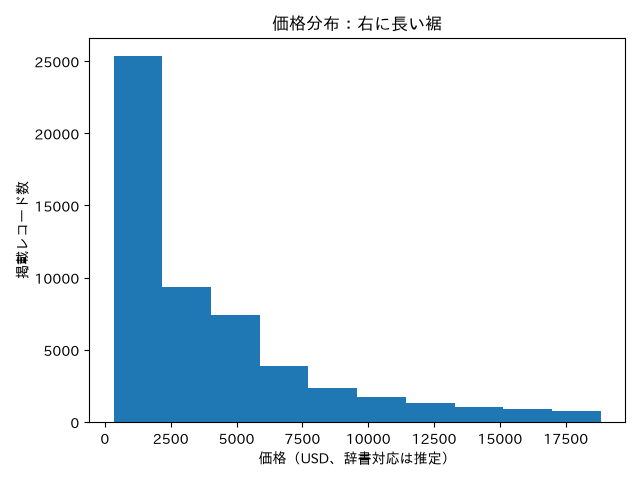

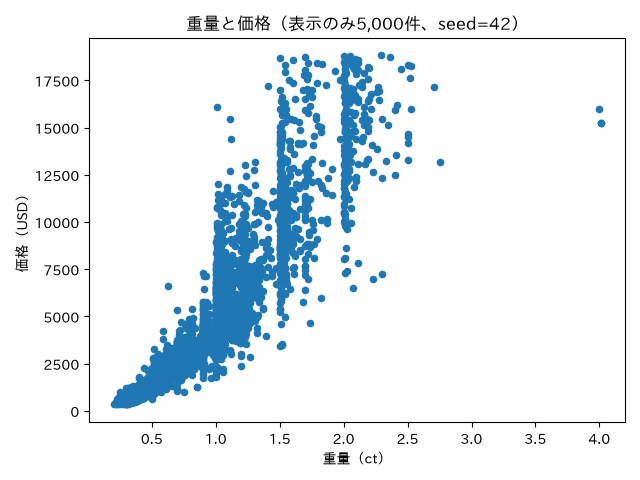

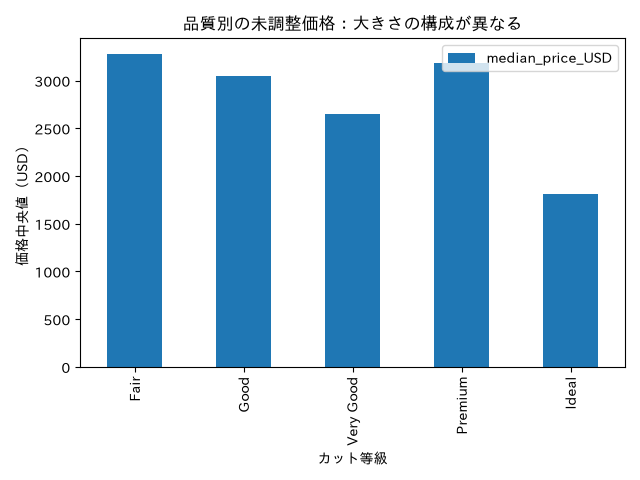

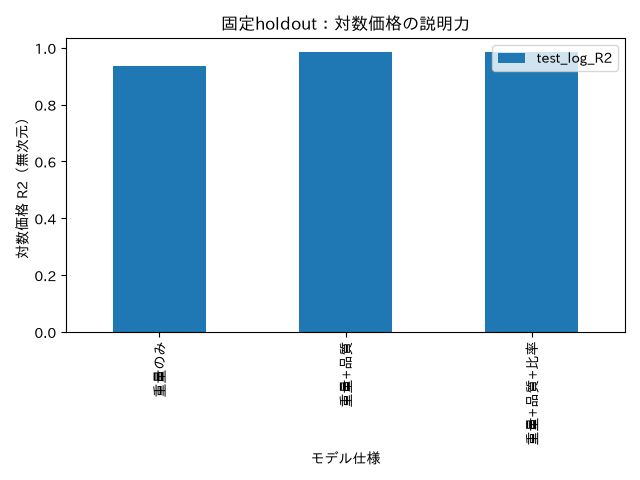

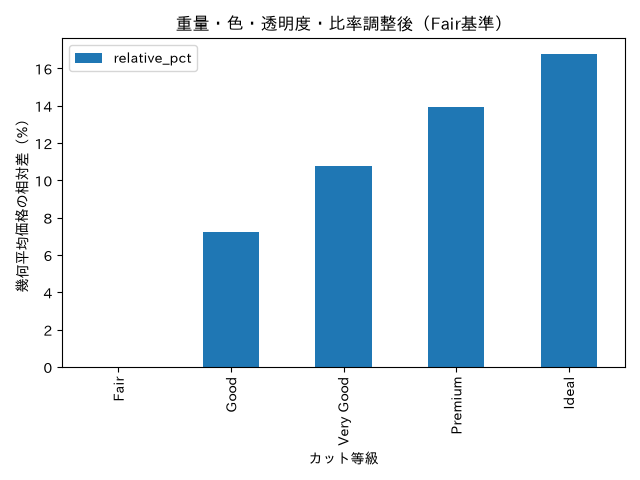

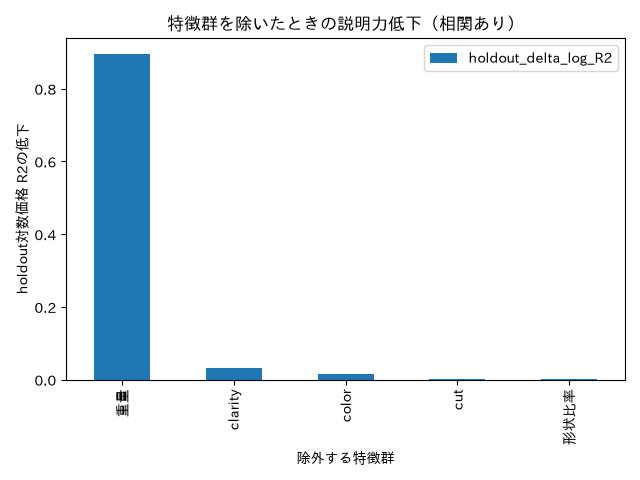

In [5]:
with phase('初回・図表'):
    import matplotlib.pyplot as plt
    plt.rcParams['figure.autolayout'] = True
    chart_specs = [
        ('price-distribution', df, 'hist', 'price', None, '価格分布：右に長い裾', '価格（USD、辞書対応は推定）', '掲載レコード数', '単一系列'),
        ('weight-price', df.sample(n=min(5000,len(df)),random_state=42), 'scatter', 'carat','price','重量と価格（表示のみ5,000件、seed=42）','重量（ct）','価格（USD）','単一系列'),
        ('raw-cut', cut_raw.reset_index(), 'bar','cut','median_price_USD','品質別の未調整価格：大きさの構成が異なる','カット等級','価格中央値（USD）','median_price_USD'),
        ('model-performance', score_table, 'bar','model','test_log_R2','固定holdout：対数価格の説明力','モデル仕様','対数価格 R2（無次元）','test_log_R2'),
        ('adjusted-cut', adjusted_table.query("feature == 'cut'"), 'bar','level','relative_pct','重量・色・透明度・比率調整後（Fair基準）','カット等級','幾何平均価格の相対差（%）','relative_pct'),
        ('group-ablation', ablation_table, 'bar','group','holdout_delta_log_R2','特徴群を除いたときの説明力低下（相関あり）','除外する特徴群','holdout対数価格 R2の低下','holdout_delta_log_R2')]
    rendered_charts=[]
    for chart_id, frame, kind, x, y, title, xlabel, ylabel, legend in chart_specs:
        with warnings.catch_warnings(record=True) as chart_warnings:
            warnings.simplefilter('always')
            png=visualization.render_chart(frame,kind=kind,x=x,y=y,title=title,xlabel=xlabel,ylabel=ylabel)
        glyph_warnings=[str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
        metadata={'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':glyph_warnings,'chart_id':chart_id}
        # 標準displayは実行MCPに出力保存を委ねる。PNG MIMEは専用builderと同じ形式。
        image_output=visualization.build_image_output(png)
        display(image_output['data'],raw=True)
        rendered_charts.append(metadata)
    print('chart_metadata:', json.dumps(rendered_charts, ensure_ascii=False))


## 反復依頼履歴

### 反復1：原文
> 初回ではIdealの未調整価格が低い一方、条件調整後はFairより高くなりました。carat・color・clarityが同一の観測層でIdealとFair、およびIdealとPremiumの対数価格差を比較し、共通支持の件数と範囲を示してください。回帰の外挿に依存する程度と、依然として因果効果ではない理由を記録してください。

選定理由：未調整と条件調整でcut価格順位が逆転し、スプライン回帰の外挿依存と共通支持を確認する必要がある。

In [6]:
with phase('反復1・同一重量品質層'):
    strata_results = []
    strata_details = {}
    for comparator in ['Fair','Premium']:
        subset = df.loc[df.cut.isin(['Ideal',comparator])].copy()
        subset['log_price'] = np.log(subset.price)
        agg = subset.groupby(['carat','color','clarity','cut'],observed=True).log_price.agg(['mean','size'])
        means = agg['mean'].unstack('cut')
        counts = agg['size'].unstack('cut').fillna(0)
        overlap = counts['Ideal'].ge(3) & counts[comparator].ge(3)
        means, counts = means.loc[overlap], counts.loc[overlap]
        assert len(means) > 0
        differences = means.Ideal-means[comparator]
        weights = 2*counts.Ideal*counts[comparator]/(counts.Ideal+counts[comparator])
        weighted_logdiff = float(np.average(differences,weights=weights))
        strata_boot_rng = np.random.default_rng(2026)
        boot=[]
        for _ in range(1000):
            ix = strata_boot_rng.integers(0,len(differences),len(differences))
            boot.append(np.average(differences.iloc[ix],weights=weights.iloc[ix]))
        ci_low,ci_high = 100*np.expm1(np.quantile(boot,[.025,.975]))
        record={'comparator':comparator,'overlap_strata':len(means),'overlap_Ideal_n':int(counts.Ideal.sum()),'overlap_comparator_n':int(counts[comparator].sum()),'subset_coverage_pct':100*float(counts.to_numpy().sum())/len(subset),'carat_min':float(means.index.get_level_values('carat').min()),'carat_max':float(means.index.get_level_values('carat').max()),'ideal_relative_pct':float(100*np.expm1(weighted_logdiff)),'strata_bootstrap_low_pct':float(ci_low),'strata_bootstrap_high_pct':float(ci_high)}
        strata_results.append(record)
        strata_details[comparator]=means.assign(log_difference=differences,overlap_weight=weights)
    strata_table=pd.DataFrame(strata_results)
    display(strata_table.round(4))
    display({'text/plain':json.dumps({'stratified_results':strata_results},ensure_ascii=False)},raw=True)
    print('根拠: carat/color/clarity完全一致層で各cut>=3。調整していないdepth/table・売主・測定誤差・選択が残る。層bootstrap区間は層の交換可能性を仮定し、市場母集団や因果効果の区間ではない。共通支持部分に限定。')


根拠: carat/color/clarity完全一致層で各cut>=3。調整していないdepth/table・売主・測定誤差・選択が残る。層bootstrap区間は層の交換可能性を仮定し、市場母集団や因果効果の区間ではない。共通支持部分に限定。


,comparator,overlap_strata,overlap_Ideal_n,overlap_comparator_n,subset_coverage_pct,carat_min,carat_max,ideal_relative_pct,strata_bootstrap_low_pct,strata_bootstrap_high_pct
0,Fair,108,1455,573,8.7561,0.30,2.01,22.2096,20.5511,23.9497
1,Premium,1073,13228,9185,63.4175,0.24,2.30,1.1020,0.5120,1.6626


{"stratified_results": [{"comparator": "Fair", "overlap_strata": 108, "overlap_Ideal_n": 1455, "overlap_comparator_n": 573, "subset_coverage_pct": 8.75609861404948, "carat_min": 0.3, "carat_max": 2.01, "ideal_relative_pct": 22.209576722213, "strata_bootstrap_low_pct": 20.55111253326218, "strata_bootstrap_high_pct": 23.94972894983004}, {"comparator": "Premium", "overlap_strata": 1073, "overlap_Ideal_n": 13228, "overlap_comparator_n": 9185, "subset_coverage_pct": 63.41746364099372, "carat_min": 0.24, "carat_max": 2.3, "ideal_relative_pct": 1.1019600858798366, "strata_bootstrap_low_pct": 0.5120374993230575, "strata_bootstrap_high_pct": 1.662614164143127}]}

### 反復2：原文
> 主要結論の仕様依存性を確かめてください。重量の対数線形モデルとスプラインモデルを比較し、全件・意味的な寸法/比率異常を除外・観測内容の重複除外・重量と価格の上下1%を除外の条件で、品質追加によるholdout対数R2の増分とIdeal対Fairの調整価格差をSensitivityPlanで検証してください。全仕様の共通holdoutを固定し、安定性の判定対象・閾値・限界を明示してください。

選定理由：意味的異常と重複を発見しており、重量の関数形と除外方針による主要結論の変化を定量化する必要がある。反復1の観測層比較と異なる頑健性を調べる。

In [7]:
with phase('反復2・仕様感度'):
    semantic_ok = ~cross_field_flags.any(axis=1) & df.table.between(40,80) & df.depth.between(40,80)
    q_carat = train.carat.quantile([.01,.99]).values
    q_price = train.price.quantile([.01,.99]).values
    trimmed = df.carat.between(*q_carat) & df.price.between(*q_price)
    unique_rows = ~df.duplicated()
    policies={'全件':pd.Series(True,index=df.index),'意味的異常除外':semantic_ok,'重複除外':unique_rows,'上下1%除外':trimmed}
    # train由来トリム境界。全仕様共通評価集合なので母集団は中心域に限定される。
    common_eval=test.loc[(semantic_ok & unique_rows & trimmed).reindex(test.index)].copy()
    sensitivity_cache={}
    def sensitivity_fit(model,subset):
        key=(model,subset)
        if key not in sensitivity_cache:
            selected_train=train.loc[policies[subset].reindex(train.index)]
            size=size_term if model=='spline' else 'np.log(carat)'
            base=smf.ols('np.log(price) ~ '+size,data=selected_train).fit()
            quality_only=smf.ols('np.log(price) ~ '+size+'+C(cut)+C(color)+C(clarity)',data=selected_train).fit()
            quality_r2=r2_score(np.log(common_eval.price),quality_only.predict(common_eval))
            extended=smf.ols('np.log(price) ~ '+size+'+C(cut)+C(color)+C(clarity)+depth+table',data=selected_train).fit()
            base_r2=r2_score(np.log(common_eval.price),base.predict(common_eval))
            extended_r2=r2_score(np.log(common_eval.price),extended.predict(common_eval))
            probe=pd.DataFrame([{**profile,'cut':'Fair'},{**profile,'cut':'Ideal'}])
            delta=float(np.diff(extended.predict(probe).values)[0])
            sensitivity_cache[key]={'model':model,'subset':subset,'train_n':len(selected_train),'common_test_n':len(common_eval),'base_log_R2':base_r2,'full_log_R2':extended_r2,'quality_gain_R2':quality_r2-base_r2,'ideal_vs_fair_pct':float(100*np.expm1(delta))}
        return sensitivity_cache[key]
    sensitivity_plan=sensitivity.SensitivityPlan(parameter_grid={'model':['spline','log-linear'],'subset':list(policies)},max_runs=8)
    quality_sensitivity=sensitivity.run_sensitivity(sensitivity_plan,lambda **spec:sensitivity_fit(**spec)['quality_gain_R2'],stability_tolerance=.2)
    cut_sensitivity=sensitivity.run_sensitivity(sensitivity_plan,lambda **spec:sensitivity_fit(**spec)['ideal_vs_fair_pct'],stability_tolerance=.2)
    sensitivity_table=pd.DataFrame(sensitivity_cache.values())
    display(sensitivity_table.round(6))
    sensitivity_summary={'quality_gain_stable':quality_sensitivity.stable,'quality_gain_max_relative_deviation':quality_sensitivity.max_relative_deviation,'cut_difference_stable':cut_sensitivity.stable,'cut_difference_max_relative_deviation':cut_sensitivity.max_relative_deviation,'tolerance':.2,'quality_gain_range': [float(sensitivity_table.quality_gain_R2.min()),float(sensitivity_table.quality_gain_R2.max())],'cut_pct_range':[float(sensitivity_table.ideal_vs_fair_pct.min()),float(sensitivity_table.ideal_vs_fair_pct.max())],'common_test_n':len(common_eval),'common_test_exclusions':len(test)-len(common_eval),'all_quality_gain_positive':bool(sensitivity_table.quality_gain_R2.gt(0).all()),'all_cut_difference_positive':bool(sensitivity_table.ideal_vs_fair_pct.gt(0).all())}
    display({'text/plain':json.dumps({'sensitivity_summary':sensitivity_summary},ensure_ascii=False)},raw=True)
    print('20%は事前に定めた実務的な相対偏差の閾値。stableは値の大きさに関する判定で、符号の一貫性とは区別。外れ値除外は価格結果でも選別するため中心域評価であり全市場に外挿しない。')


20%は事前に定めた実務的な相対偏差の閾値。stableは値の大きさに関する判定で、符号の一貫性とは区別。外れ値除外は価格結果でも選別するため中心域評価であり全市場に外挿しない。


,model,subset,train_n,common_test_n,base_log_R2,full_log_R2,quality_gain_R2,ideal_vs_fair_pct
0,spline,全件,43159,10376,0.932137,0.984029,0.051879,16.786151
1,spline,意味的異常除外,43101,10376,0.932138,0.984029,0.051878,16.755024
2,spline,重複除外,43036,10376,0.932132,0.984030,0.051883,16.806624
3,spline,上下1%除外,41829,10376,0.932287,0.984117,0.051814,16.987330
4,log-linear,全件,43159,10376,0.929447,0.981816,0.052366,16.998183
5,log-linear,意味的異常除外,43101,10376,0.929448,0.981816,0.052365,17.007815
6,log-linear,重複除外,43036,10376,0.929452,0.981820,0.052365,17.002274
7,log-linear,上下1%除外,41829,10376,0.929465,0.981831,0.052363,17.036858


{"sensitivity_summary": {"quality_gain_stable": true, "quality_gain_max_relative_deviation": 0.009406334909225548, "cut_difference_stable": true, "cut_difference_max_relative_deviation": 0.014935373302238882, "tolerance": 0.2, "quality_gain_range": [0.05181420525675062, 0.05236649621270906], "cut_pct_range": [16.755023670644086, 17.036857999240006], "common_test_n": 10376, "common_test_exclusions": 405, "all_quality_gain_positive": true, "all_cut_difference_positive": true}}

### 反復3：原文
> 層比較のIdeal対Fair差が回帰推定より大きく、共通支持も狭いため、品質差を全重量域に一定とみなす未解決点が残ります。品質と対数重量の交互作用、および寸法x/y/zから得られる体積・形状情報を追加し、異常寸法を除いた共通holdoutで説明力を比較してください。重量帯別残差、重量別のIdeal対Fair差、品質群の条件付き重要度を確認し、初回結論を必要なら限定してください。

選定理由：Fairとの同一層比較は対象の8.8%に限定され、加法モデルの一律比率と層比較が異なる。全特徴を扱うため寸法の追加情報と品質×重量の異質性、残差帯別偏りを確認する。

In [8]:
with phase('反復3・交互作用と寸法・残差'):
    valid_rows = ~cross_field_flags.any(axis=1) & df.depth.between(40,80) & df.table.between(40,80)
    train_valid=train.loc[valid_rows.reindex(train.index)].copy()
    test_valid=test.loc[valid_rows.reindex(test.index)].copy()
    category_levels={'cut':['Fair','Good','Very Good','Premium','Ideal'],'color':list('DEFGHIJ'),'clarity':['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']}
    def interaction_terms(groups):
        return ' + '.join(f'I(np.log(carat) * ({g} == {level!r}))' for g in groups for level in category_levels[g][1:])
    interaction=interaction_terms(list(category_levels))
    geometry='np.log(x*y*z) + I(x/y) + I(z/((x+y)/2))'
    diagnostic_formulas={'初回加法':full_formula,'品質×重量':full_formula+' + '+interaction,'品質×重量+寸法':full_formula+' + '+interaction+' + '+geometry}
    diagnostic_models={}
    diagnostic_records=[]
    for name, formula in diagnostic_formulas.items():
        fitted=smf.ols(formula,data=train_valid).fit()
        assert fitted.model.rank == fitted.model.exog.shape[1], 'ランク欠損モデルは解釈しない'
        diagnostic_models[name]=fitted
        predicted=fitted.predict(test_valid)
        diagnostic_records.append({'model':name,'test_n':len(test_valid),'log_R2':r2_score(np.log(test_valid.price),predicted),'log_RMSE':float(np.sqrt(np.mean((np.log(test_valid.price)-predicted)**2)))})
    diagnostic_table=pd.DataFrame(diagnostic_records)
    display(diagnostic_table.round(6))
    interaction_fit=diagnostic_models['品質×重量']
    revised_ablation=[]
    for group in ['cut','color','clarity']:
        remaining=[g for g in ['cut','color','clarity'] if g!=group]
        reduced_formula='np.log(price) ~ '+size_term+' + depth + table + '+' + '.join('C('+g+')' for g in remaining)+' + '+interaction_terms(remaining)
        reduced_fit=smf.ols(reduced_formula,data=train_valid).fit()
        assert reduced_fit.model.rank == reduced_fit.model.exog.shape[1], 'ランク欠損モデルは解釈しない'
        delta=diagnostic_records[1]['log_R2']-r2_score(np.log(test_valid.price),reduced_fit.predict(test_valid))
        revised_ablation.append({'group':group,'holdout_delta_log_R2_with_interactions':delta})
    display(pd.DataFrame(revised_ablation).round(6))
    weight_contrasts=[]
    for weight in [.3,.5,1.,1.5,2.]:
        probe=pd.DataFrame([{**profile,'carat':weight,'cut':'Fair'},{**profile,'carat':weight,'cut':'Ideal'}])
        logdifference=float(np.diff(interaction_fit.predict(probe).values)[0])
        near=df.loc[df.carat.between(weight-.05,weight+.05)]
        weight_contrasts.append({'carat':weight,'ideal_vs_fair_pct':float(100*np.expm1(logdifference)),'near_Fair_n':int(near.cut.eq('Fair').sum()),'near_Ideal_n':int(near.cut.eq('Ideal').sum())})
    weight_contrast_table=pd.DataFrame(weight_contrasts)
    display(weight_contrast_table.round(4))
    residual_table=[]
    for name,fitted in diagnostic_models.items():
        errors=fitted.predict(test_valid)-np.log(test_valid.price)
        band=pd.cut(test_valid.carat,[0,.5,1,1.5,2,np.inf],right=False)
        for label,ix in band.groupby(band,observed=True).groups.items():
            e=errors.loc[ix]
            residual_table.append({'model':name,'weight_band':str(label),'n':len(e),'mean_log_error_pred_minus_actual':float(e.mean()),'median_relative_error_pct':float(100*np.expm1(e.median())),'log_RMSE':float(np.sqrt(np.mean(e**2)))})
    residual_table=pd.DataFrame(residual_table)
    display(residual_table.round(5))
    diagnostic_summary={'models':diagnostic_records,'interaction_gain_log_R2':diagnostic_records[1]['log_R2']-diagnostic_records[0]['log_R2'],'dimension_gain_log_R2':diagnostic_records[2]['log_R2']-diagnostic_records[1]['log_R2'],'weight_contrasts':weight_contrasts,'quality_ablation':revised_ablation}
    display({'text/plain':json.dumps({'diagnostic_summary':diagnostic_summary},ensure_ascii=False)},raw=True)
    print('残る限界: 交互作用でも観測価格の関連に過ぎない。近傍件数は全色/透明度合計で、プロファイルの完全共通支持を保証しない。重量2ct以上は少数・高価格域で一般化を制限。最大3回に達したので追加探索はここで停止し、未検証の売主/日付/鑑定依存は限界として残す。')


残る限界: 交互作用でも観測価格の関連に過ぎない。近傍件数は全色/透明度合計で、プロファイルの完全共通支持を保証しない。重量2ct以上は少数・高価格域で一般化を制限。最大3回に達したので追加探索はここで停止し、未検証の売主/日付/鑑定依存は限界として残す。


,model,test_n,log_R2,log_RMSE
0,初回加法,10767,0.984962,0.125414
1,品質×重量,10767,0.985598,0.122734
2,品質×重量+寸法,10767,0.985741,0.122125


,group,holdout_delta_log_R2_with_interactions
0,cut,0.001126
1,color,0.015947
2,clarity,0.031625


,carat,ideal_vs_fair_pct,near_Fair_n,near_Ideal_n
0,0.3,5.8146,51,5495
1,0.5,10.7449,145,2671
2,1.0,17.8044,414,1523
3,1.5,22.1408,143,600
4,2.0,25.3139,97,236


,model,weight_band,n,mean_log_error_pred_minus_actual,median_relative_error_pct,log_RMSE
0,初回加法,"[0.0, 0.5)",3529,0.01005,3.46922,0.13291
1,初回加法,"[0.5, 1.0)",3376,0.00006,-0.16794,0.10976
2,初回加法,"[1.0, 1.5)",2588,-0.00536,-1.30591,0.12845
3,初回加法,"[1.5, 2.0)",845,-0.00015,-2.43590,0.12591
4,初回加法,"[2.0, inf)",429,-0.03032,-6.47496,0.15454
5,品質×重量,"[0.0, 0.5)",3529,0.01031,2.77135,0.12799
6,品質×重量,"[0.5, 1.0)",3376,-0.00007,-0.25020,0.11011
7,品質×重量,"[1.0, 1.5)",2588,-0.00519,-1.08531,0.12423
8,品質×重量,"[1.5, 2.0)",845,-0.00550,-2.45990,0.12845
9,品質×重量,"[2.0, inf)",429,-0.03060,-4.43243,0.14933


{"diagnostic_summary": {"models": [{"model": "初回加法", "test_n": 10767, "log_R2": 0.984962129033877, "log_RMSE": 0.1254144307781304}, {"model": "品質×重量", "test_n": 10767, "log_R2": 0.9855981452378861, "log_RMSE": 0.12273362112242946}, {"model": "品質×重量+寸法", "test_n": 10767, "log_R2": 0.985740567544255, "log_RMSE": 0.12212524684172579}], "interaction_gain_log_R2": 0.0006360162040091044, "dimension_gain_log_R2": 0.00014242230636885012, "weight_contrasts": [{"carat": 0.3, "ideal_vs_fair_pct": 5.814564935771723, "near_Fair_n": 51, "near_Ideal_n": 5495}, {"carat": 0.5, "ideal_vs_fair_pct": 10.744947231481994, "near_Fair_n": 145, "near_Ideal_n": 2671}, {"carat": 1.0, "ideal_vs_fair_pct": 17.804432611554162, "near_Fair_n": 414, "near_Ideal_n": 1523}, {"carat": 1.5, "ideal_vs_fair_pct": 22.140779308690465, "near_Fair_n": 143, "near_Ideal_n": 600}, {"carat": 2.0, "ideal_vs_fair_pct": 25.313927992780787, "near_Fair_n": 97, "near_Ideal_n": 236}], "quality_ablation": [{"group": "cut", "holdout_delta_l

## 反復結果の図表

共通支持の層比較と、交互作用による重量別差を別々に表示する。尺度・対象が違うため同じ母集団の推定値として混同しない。

chart_metadata: [{"title": "同一重量・色・透明度層の比較（共通支持のみ）", "xlabel": "Idealと比較する等級", "ylabel": "幾何平均価格差（%）", "legend": "ideal_relative_pct", "missing_glyphs": [], "chart_id": "stratified-cut"}, {"title": "交互作用モデル：cut差は重量で変化する", "xlabel": "重量（ct）", "ylabel": "Ideal対Fairのモデル価格差（%）", "legend": "ideal_vs_fair_pct", "missing_glyphs": [], "chart_id": "heterogeneous-cut"}]


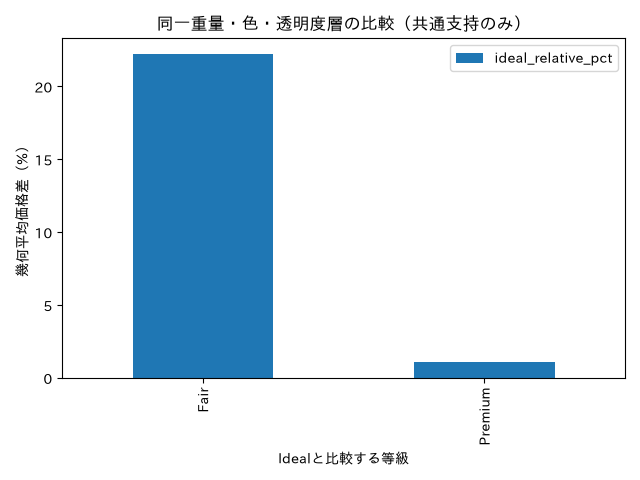

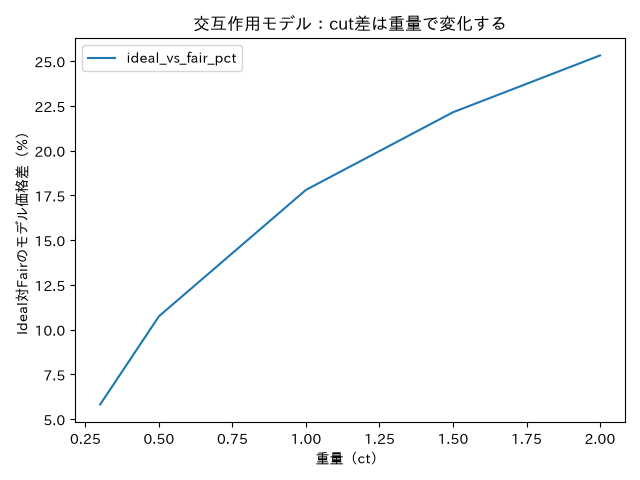

In [9]:
with phase('反復結果・追加図表'):
    extra_chart_specs=[('stratified-cut',strata_table,'bar','comparator','ideal_relative_pct','同一重量・色・透明度層の比較（共通支持のみ）','Idealと比較する等級','幾何平均価格差（%）','ideal_relative_pct'),('heterogeneous-cut',weight_contrast_table,'line','carat','ideal_vs_fair_pct','交互作用モデル：cut差は重量で変化する','重量（ct）','Ideal対Fairのモデル価格差（%）','ideal_vs_fair_pct')]
    extra_rendered_charts=[]
    for chart_id,frame,kind,x,y,title,xlabel,ylabel,legend in extra_chart_specs:
        with warnings.catch_warnings(record=True) as observed_warnings:
            warnings.simplefilter('always')
            png=visualization.render_chart(frame,kind=kind,x=x,y=y,title=title,xlabel=xlabel,ylabel=ylabel)
        metadata={'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':[str(w.message) for w in observed_warnings if 'Glyph' in str(w.message)],'chart_id':chart_id}
        display(visualization.build_image_output(png)['data'],raw=True)
        extra_rendered_charts.append(metadata)
    print('chart_metadata:',json.dumps(extra_rendered_charts,ensure_ascii=False))


## 使用したJupytermindモジュール

直接import・呼出しのみを列挙。下記の接頭辞はすべて`ai_data_scientist.`。内部依存を使用済みとして数えない。

| モジュール | 直接使用した関数・型 | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定保存先の解決、データ/Notebook作成、直列書込み |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_idと実行・書込み・終了状態管理 |
| language_router | detect_language | 日本語指定の確認 |
| ingestion | SourceSpec, ingest | 保存CSVの読込、100,000行上限と非切捨て確認 |
| cleaning | clean_dataset | 欠損除去の影響報告、行番号を除いた重複計数/感度分析 |
| eda | explore | 欠損、型、要約、カテゴリ件数 |
| stats_analysis | correlation | carat–priceのPearson相関と日本語解釈 |
| visualization | render_chart, build_image_output | 日本語図8枚とPNG MIME出力 |
| insight_engine | extract_cited_value, record_insight, EvidenceMissingError | 実行済み出力から正確な値を抽出、根拠付きInsight、互換性再現確認 |
| notebook_audit | audit_notebook, audit_visual_outputs | 実行/根拠/visual_audit=True監査とメタデータ欠落の再現 |
| data_definition | FieldValue, build_manifest, manifest.unresolved_fields | 単位・定義・出典の確信度記録と不明/推定の表面化 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 関連の範囲、仮定リスク、検証済み仮定の記録 |
| data_quality | detect_anomalies | 0寸法、不合理範囲、カテゴリ等の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 2モデル×4前処理の感度分析、相対偏差20%判定 |

### 非適用・使用しなかった機能
mcp_gatewayはimport・呼出ししていない。ホストのJupyter MCPセル実行を直接使用し、カーネルにMCPクライアントが注入されない環境でローカルexecをMCP実行と偽らない。独立した参照データセットがないためdata_quality.validate_anomaliesとdataset_validation.compare_datasetsは非適用。anomaly_detectionの正規z-score検査は右裾が長い価格を誤り扱いしかねないため用いず、宣言制約・多列整合性・除外感度を使用。因果推定は時点/販売過程/介入/識別戦略がないため非適用。SDKによる公開データのカタログ検索はKaggleApiで行い、Jupytermindのデータセット比較機能による自動発見とは区別する。


## Jupytermind改善候補

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| 可視化・レイアウト不足 | render_chartの既定設定で日本語カテゴリの縦向きtickを持つbar図を保存 | 下端のtick/軸ラベルまで収まる | 初回のモデル比較図等で下端が切れた | 図の読み取りが困難 | figure.autolayout=Trueを呼出し前に設定 | セル7、data/layout-before-model-performance.png、セル15の修正版図 |
| 可視化監査・検査不足 | PNGを含む実行済みコードセルのmetadata.chartを空にしてaudit_visual_outputs | 必須のglyph/title/axis/legend監査メタデータ欠落を警告 | findingsが空になる | メタデータが欠けた図を監査合格と誤認し得る | 呼出し側で全画像のラベル/字形warningを検査しセルと出力双方に明示metadataを保存 | セル18、data/jupytermind-improvement-probes.json |
| 根拠エンジン・出力互換性不足 | 実行済みJupyterセルの数値をstdout streamに置きrecord_insight | stream内の数値も根拠として検出 | EvidenceMissingErrorになる（エラー全文は再現ログに保存） | print値のみを根拠とするInsightを記録できない | display_data text/plainにもJSON値を表示し、その実出力から抽出 | セル4/6/9/11/13の数値出力、セル18の最小再現、同JSONログ |

いずれもライブラリのAPI/保存/監査仕様に対応する候補で、Kaggle認証/APIやベンチマークランナーの不具合ではない。MCPが標準streamを生成すること自体は正常。CLIでの長出力省略は分析結果の欠落ではなくNotebookには全出力が残る。最初の辞書assertion（carats/car​atの表記差）と交互作用のランク欠損は分析コード側の問題として修正済みで、Jupytermind改善候補には含めない。修正履歴はNotebook metadata.execution_notes。


In [10]:
with phase('Jupytermind改善候補・再現確認'):
    from dataclasses import replace
    probe_handle=replace(handle,notebook_path=data_dir/'temporary-api-probe.ipynb')
    lifecycle.mark_write_start(RUN_ID)
    try:
        project_manager.ensure_notebook(probe_handle)
        def seed_probe(nb):
            nb.cells=[nbformat.v4.new_code_cell('print(0.5)',execution_count=1,outputs=[nbformat.v4.new_output('stream',name='stdout',text='0.5\n')])]
        project_manager.enqueue_write(probe_handle,seed_probe)
    finally:
        lifecycle.mark_write_end(RUN_ID)
    evidence_stream_issue=None
    try:
        insight_engine.record_insight(probe_handle,'probe',1,'0.5','associational',language='ja')
    except insight_engine.EvidenceMissingError as exc:
        evidence_stream_issue={'classification':'機能不足・MCP出力互換性','expected':'正常に実行されたJupyter stream出力も数値根拠として認識','actual':type(exc).__name__,'impact':'printで得た値を根拠登録できない','workaround':'display_data/execute_resultのtext/plainとして値を保存','cell':18,'log':str(exc)}
    visual_probe=nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('chart_probe',execution_count=1,outputs=[visualization.build_image_output(png)])])
    visual_without_metadata=notebook_audit.audit_visual_outputs(visual_probe,(0,))
    module_probe_results={'stream_evidence':evidence_stream_issue,'visual_missing_metadata_findings':[asdict(f) for f in visual_without_metadata],'layout_before_artifact':str(data_dir/'layout-before-model-performance.png'),'layout_workaround':'matplotlib rcParams figure.autolayout=True'}
    print(json.dumps(module_probe_results,ensure_ascii=False,indent=2))
    (data_dir/'jupytermind-improvement-probes.json').write_text(json.dumps(module_probe_results,ensure_ascii=False,indent=2))
    probe_handle.notebook_path.unlink()


{
  "stream_evidence": {
    "classification": "機能不足・MCP出力互換性",
    "expected": "正常に実行されたJupyter stream出力も数値根拠として認識",
    "actual": "EvidenceMissingError",
    "impact": "printで得た値を根拠登録できない",
    "workaround": "display_data/execute_resultのtext/plainとして値を保存",
    "cell": 18,
    "log": "Insight 'probe' に根拠となる実行済みセル(execution_count=1)が見つからないため記録を保留しました。"
  },
  "visual_missing_metadata_findings": [],
  "layout_before_artifact": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-05-diamonds/data/layout-before-model-performance.png",
  "layout_workaround": "matplotlib rcParams figure.autolayout=True"
}


## 根拠付きInsightと残る限界

下記は最終セルが実行済み数値から自動更新する。USD/ct/mmは公開ggplot2辞書との対応に基づく推定。Kaggle独自の測定/価格時点/市場代表性は不明で、単位対応とレコードの独立性に関するassumption警告を残す。記載のR2は固定holdout内の観察的説明力で、探索にholdoutを再利用しているため外部データに対する保証にはならない。寸法20mmやdepth差2pp等は検査閾値で、真の誤入力とは断定しない。

Insight 1｜大きさが価格差の主軸。caratとpriceのPearson相関は0.9216、Spearmanは0.9629。ただし相関は因果を示さない。寸法ゼロ/20mm超が23件あり、主モデルは寸法に依存させず、行番号を除いた146件の重複も感度分析で扱った。

```evidence
{"execution_count":3,"cited_value":"{\"pearson\": 0.9215913011934768, \"spearman\": 0.9628827988813001, \"rows\": 53940, \"duplicates\": 146, \"invalid_dimensions\": 23}","claim_type":"associational"}
```

Insight 2｜固定holdoutで重量のみの対数価格R2は0.9356、品質追加は0.9850、比率追加は0.9850。品質を加えるとUSD MAEは約844から396へ低下した。群除外と反復3でも透明度、色、カットの順に独自の追加説明力が大きい。R2は観察的・対数尺度の説明力であり、因果的寄与率ではない。

```evidence
{"execution_count":4,"cited_value":"{\"size_only_log_R2\": 0.9356245415575064, \"full_log_R2\": 0.9849644665031242, \"quality_gain_R2\": 0.04932630531206639, \"ideal_vs_fair_pct\": 16.78615057410811}","claim_type":"associational"}
```

Insight 3｜カットの単純な価格順位には大きさの交絡がある。Idealの未調整中央値は1810、Fairは3282で、平均重量はそれぞれ0.703ctと1.046ct。初回加法モデルで1ct・G・VS2・共通depth/tableに固定するとIdealはFairより約16.8%高い。ただし反復3からこの差を全重量に一律適用してはならない。

```evidence
{"execution_count":4,"cited_value":"{\"size_only_log_R2\": 0.9356245415575064, \"full_log_R2\": 0.9849644665031242, \"quality_gain_R2\": 0.04932630531206639, \"ideal_vs_fair_pct\": 16.78615057410811}","claim_type":"associational"}
```

Insight 4／反復1結果｜carat/color/clarity完全一致層ではIdeal対Fairの価格差は22.21%（108層）、対Premiumは1.10%（1,073層）。Fair比較は対象2等級の8.76%だけの共通支持なので全体の差とは異なる。層bootstrap区間と件数はセル9に保存。depth/tableや売主等の交絡、丸められた重量、観測選択が残り、因果効果とは呼ばない。

```evidence
{"execution_count":6,"cited_value":"{\"stratified_results\": [{\"comparator\": \"Fair\", \"overlap_strata\": 108, \"overlap_Ideal_n\": 1455, \"overlap_comparator_n\": 573, \"subset_coverage_pct\": 8.75609861404948, \"carat_min\": 0.3, \"carat_max\": 2.01, \"ideal_relative_pct\": 22.209576722213, \"strata_bootstrap_low_pct\": 20.55111253326218, \"strata_bootstrap_high_pct\": 23.94972894983004}, {\"comparator\": \"Premium\", \"overlap_strata\": 1073, \"overlap_Ideal_n\": 13228, \"overlap_comparator_n\": 9185, \"subset_coverage_pct\": 63.41746364099372, \"carat_min\": 0.24, \"carat_max\": 2.3, \"ideal_relative_pct\": 1.1019600858798366, \"strata_bootstrap_low_pct\": 0.5120374993230575, \"strata_bootstrap_high_pct\": 1.662614164143127}]}","claim_type":"associational"}
```

Insight 5／反復2結果｜8仕様・共通holdout 10,376件で品質追加のR2増分は全て正。quality_gain stable=True、max_relative_deviation=0.009406。Ideal対Fair差はTrue、max_relative_deviation=0.014935（判定閾値0.20）、約16.76–17.04%。除外・関数形に対する方向と大きさはこの範囲では維持。ただし共通評価は中心域であり、加法モデルの比較であって重量別差の一定性を保証しない。

```evidence
{"execution_count":7,"cited_value":"{\"sensitivity_summary\": {\"quality_gain_stable\": true, \"quality_gain_max_relative_deviation\": 0.009406334909225548, \"cut_difference_stable\": true, \"cut_difference_max_relative_deviation\": 0.014935373302238882, \"tolerance\": 0.2, \"quality_gain_range\": [0.05181420525675062, 0.05236649621270906], \"cut_pct_range\": [16.755023670644086, 17.036857999240006], \"common_test_n\": 10376, \"common_test_exclusions\": 405, \"all_quality_gain_positive\": true, \"all_cut_difference_positive\": true}}","claim_type":"associational"}
```

Insight 6／反復3結果｜品質×重量の交互作用による対数R2増分は0.000636、寸法の追加は0.000142。重量・品質が既知なら寸法の独自情報は小さい。交互作用モデルのIdeal対Fair差は0.3ctで5.8%、1ctで17.8%、2ctで25.3%と変化。透明度/色/cutの順位は維持するが、2ct以上の残差偏りと少数例が残る。加法の約17%は参照条件の要約に限定し、市場全体の因果的premiumとはしない。最大3回の反復で終了。

```evidence
{"execution_count":8,"cited_value":"{\"diagnostic_summary\": {\"models\": [{\"model\": \"\u521d\u56de\u52a0\u6cd5\", \"test_n\": 10767, \"log_R2\": 0.984962129033877, \"log_RMSE\": 0.1254144307781304}, {\"model\": \"\u54c1\u8cea\u00d7\u91cd\u91cf\", \"test_n\": 10767, \"log_R2\": 0.9855981452378861, \"log_RMSE\": 0.12273362112242946}, {\"model\": \"\u54c1\u8cea\u00d7\u91cd\u91cf+\u5bf8\u6cd5\", \"test_n\": 10767, \"log_R2\": 0.985740567544255, \"log_RMSE\": 0.12212524684172579}], \"interaction_gain_log_R2\": 0.0006360162040091044, \"dimension_gain_log_R2\": 0.00014242230636885012, \"weight_contrasts\": [{\"carat\": 0.3, \"ideal_vs_fair_pct\": 5.814564935771723, \"near_Fair_n\": 51, \"near_Ideal_n\": 5495}, {\"carat\": 0.5, \"ideal_vs_fair_pct\": 10.744947231481994, \"near_Fair_n\": 145, \"near_Ideal_n\": 2671}, {\"carat\": 1.0, \"ideal_vs_fair_pct\": 17.804432611554162, \"near_Fair_n\": 414, \"near_Ideal_n\": 1523}, {\"carat\": 1.5, \"ideal_vs_fair_pct\": 22.140779308690465, \"near_Fair_n\": 143, \"near_Ideal_n\": 600}, {\"carat\": 2.0, \"ideal_vs_fair_pct\": 25.313927992780787, \"near_Fair_n\": 97, \"near_Ideal_n\": 236}], \"quality_ablation\": [{\"group\": \"cut\", \"holdout_delta_log_R2_with_interactions\": 0.0011260703892860269}, {\"group\": \"color\", \"holdout_delta_log_R2_with_interactions\": 0.015947440872443375}, {\"group\": \"clarity\", \"holdout_delta_log_R2_with_interactions\": 0.03162469255821687}]}}","claim_type":"associational"}
```

In [ ]:
with phase('結果・根拠リンク・監査準備'):
    baseline=json.loads((data_dir/'initial-verification-metrics.json').read_text())
    actual={'sha256':provenance['sha256'],'rows':len(df),'size_log_R2':model_scores[0]['test_log_R2'],'full_log_R2':full_r2,'stratified_Fair_pct':strata_results[0]['ideal_relative_pct'],'stratified_Premium_pct':strata_results[1]['ideal_relative_pct'],'interaction_log_R2':diagnostic_records[1]['log_R2'],'geometry_log_R2':diagnostic_records[2]['log_R2']}
    for key,value in actual.items():
        if isinstance(value,float):
            assert np.isclose(value,baseline[key],rtol=1e-9,atol=1e-9),(key,value,baseline[key])
        else:
            assert value==baseline[key],(key,value,baseline[key])
    current_nb=nbformat.read(handle.notebook_path,as_version=4)
    counts=[c.execution_count for c in current_nb.cells if c.cell_type=='code' and not c.source.startswith("with phase('結果・根拠")]
    assert all(isinstance(c,int) for c in counts) and counts==sorted(counts) and len(counts)==len(set(counts)), '全セルの上からの実行順が不整合'
    def attach_chart_metadata(nb):
        for index,metadata_list in [(7,rendered_charts),(15,extra_rendered_charts)]:
            image_outputs=[o for o in nb.cells[index].outputs if 'image/png' in o.get('data',{})]
            assert len(image_outputs)==len(metadata_list)
            for output,metadata in zip(image_outputs,metadata_list):
                assert not metadata['missing_glyphs'],metadata
                assert all(metadata.get(k) for k in ['title','xlabel','ylabel','legend'])
                output.setdefault('metadata',{})['chart']=metadata
            nb.cells[index].metadata['charts']=metadata_list
            nb.cells[index].metadata['chart']={key:' / '.join(m[key] for m in metadata_list) for key in ['title','xlabel','ylabel','legend']}
            nb.cells[index].metadata['chart']['missing_glyphs']=[]
        nb.metadata['reexecution']={'kernel_restarted_via':'jupyter-restart_notebook','all_preceding_code_counts':counts,'metrics_equal_to_first_analysis':True,'comparison_rtol':1e-9,'comparison_atol':1e-9,'data_sha256':actual['sha256']}
    write_notebook(attach_chart_metadata)
    evidence_sources=[(4,'pearson'),(6,'size_only_log_R2'),(6,'size_only_log_R2'),(9,'stratified_results'),(11,'sensitivity_summary'),(13,'diagnostic_summary')]
    texts=[
        f'Insight 1｜大きさが価格差の主軸。caratとpriceのPearson相関は{correlation_result.statistic:.4f}、Spearmanは{spearman:.4f}。ただし相関は因果を示さない。寸法ゼロ/20mm超が23件あり、主モデルは寸法に依存させず、行番号を除いた146件の重複も感度分析で扱った。',
        f'Insight 2｜固定holdoutで重量のみの対数価格R2は{model_scores[0]["test_log_R2"]:.4f}、品質追加は{model_scores[1]["test_log_R2"]:.4f}、比率追加は{full_r2:.4f}。品質を加えるとUSD MAEは約{model_scores[0]["test_USD_MAE_smearing"]:.0f}から{model_scores[1]["test_USD_MAE_smearing"]:.0f}へ低下した。群除外と反復3でも透明度、色、カットの順に独自の追加説明力が大きい。R2は観察的・対数尺度の説明力であり、因果的寄与率ではない。',
        f'Insight 3｜カットの単純な価格順位には大きさの交絡がある。Idealの未調整中央値は{cut_raw.loc["Ideal","median_price_USD"]:.0f}、Fairは{cut_raw.loc["Fair","median_price_USD"]:.0f}で、平均重量はそれぞれ{cut_raw.loc["Ideal","mean_carat"]:.3f}ctと{cut_raw.loc["Fair","mean_carat"]:.3f}ct。初回加法モデルで1ct・G・VS2・共通depth/tableに固定するとIdealはFairより約{adjusted_table.query("feature == 'cut' and level == 'Ideal'").relative_pct.iloc[0]:.1f}%高い。ただし反復3からこの差を全重量に一律適用してはならない。',
        f'Insight 4／反復1結果｜carat/color/clarity完全一致層ではIdeal対Fairの価格差は{strata_results[0]["ideal_relative_pct"]:.2f}%（108層）、対Premiumは{strata_results[1]["ideal_relative_pct"]:.2f}%（1,073層）。Fair比較は対象2等級の{strata_results[0]["subset_coverage_pct"]:.2f}%だけの共通支持なので全体の差とは異なる。層bootstrap区間と件数はセル9に保存。depth/tableや売主等の交絡、丸められた重量、観測選択が残り、因果効果とは呼ばない。',
        f'Insight 5／反復2結果｜8仕様・共通holdout {len(common_eval):,}件で品質追加のR2増分は全て正。quality_gain stable={quality_sensitivity.stable}、max_relative_deviation={quality_sensitivity.max_relative_deviation:.6f}。Ideal対Fair差は{cut_sensitivity.stable}、max_relative_deviation={cut_sensitivity.max_relative_deviation:.6f}（判定閾値0.20）、約{sensitivity_table.ideal_vs_fair_pct.min():.2f}–{sensitivity_table.ideal_vs_fair_pct.max():.2f}%。除外・関数形に対する方向と大きさはこの範囲では維持。ただし共通評価は中心域であり、加法モデルの比較であって重量別差の一定性を保証しない。',
        f'Insight 6／反復3結果｜品質×重量の交互作用による対数R2増分は{diagnostic_summary["interaction_gain_log_R2"]:.6f}、寸法の追加は{diagnostic_summary["dimension_gain_log_R2"]:.6f}。重量・品質が既知なら寸法の独自情報は小さい。交互作用モデルのIdeal対Fair差は0.3ctで{weight_contrasts[0]["ideal_vs_fair_pct"]:.1f}%、1ctで{weight_contrasts[2]["ideal_vs_fair_pct"]:.1f}%、2ctで{weight_contrasts[4]["ideal_vs_fair_pct"]:.1f}%と変化。透明度/色/cutの順位は維持するが、2ct以上の残差偏りと少数例が残る。加法の約17%は参照条件の要約に限定し、市場全体の因果的premiumとはしない。最大3回の反復で終了。'
    ]
    for slot,(cell_index,key),text in zip(range(20,26),evidence_sources,texts):
        evidence_nb=nbformat.read(handle.notebook_path,as_version=4)
        source_cell=evidence_nb.cells[cell_index]
        output_text='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in source_cell.outputs)
        cited=insight_engine.extract_cited_value({'output':output_text},r'(\{"'+key+r'":.*\})')
        lifecycle.mark_write_start(RUN_ID)
        try:
            insight_engine.record_insight(handle,text,source_cell.execution_count,cited,'associational',language='ja')
        finally:
            lifecycle.mark_write_end(RUN_ID)
        def place_insight(nb,target=slot):
            recorded=nb.cells.pop()
            assert recorded.cell_type=='markdown' and '```evidence' in recorded.source
            recorded.metadata['generated_insight']=True
            nb.cells[target]=recorded
        write_notebook(place_insight)
    final_assumptions=analysis_assumptions.AnalysisAssumptionManifest(analysis_scope=assumed_manifest.analysis_scope,assumptions=assumed_manifest.assumptions+(analysis_assumptions.Assumption('preprocessing-and-form', '重複/異常/トリム・線形/スプラインの8仕様で主結論を検証', 'tested',evidence_cell=11,conclusion_critical=True),analysis_assumptions.Assumption('constant-cut-premium', 'カット価格差が全重量で一定という解釈は採用しない', 'rejected',evidence_cell=13,conclusion_critical=False)),causal_scope='associational',sampling=assumed_manifest.sampling)
    final_findings=analysis_assumptions.check_manifest(final_assumptions)
    print('残る前提警告:',json.dumps([asdict(f) for f in final_findings],ensure_ascii=False))
    (data_dir/'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(final_assumptions),ensure_ascii=False,indent=2))
    (data_dir/'verified-reexecution-metrics.json').write_text(json.dumps(actual,ensure_ascii=False,indent=2))

def persist_post_execution_audit():
    report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not report.ok:
        lifecycle.mark_failed(RUN_ID)
        print(json.dumps(asdict(report),ensure_ascii=False,indent=2))
        raise RuntimeError('Notebook監査未合格')
    lifecycle.mark_completed(RUN_ID)
    def save_audit(nb):
        nb.metadata['notebook_audit']={**asdict(report),'ok':report.ok,'visual_audit':True,'checked_at_utc':datetime.now(timezone.utc).isoformat()}
        nb.metadata['lifecycle']=asdict(lifecycle.get_run_status(RUN_ID))
        nb.metadata['phase_log']=phase_log
        nb.metadata['final_report']={'rows':len(df),'provenance':provenance,'model_scores':model_scores,'sensitivity':sensitivity_summary,'diagnostics':diagnostic_summary,'remaining_assumption_findings':[asdict(f) for f in final_findings]}
    write_notebook(save_audit)
    status=lifecycle.wait_for_quiescence(RUN_ID)
    # 書込み中ではなく、終了後のスナップショットをNotebookへ記録。
    project_manager.enqueue_write(handle,lambda nb:nb.metadata.update({'lifecycle':asdict(status),'phase_log':phase_log}))
    (data_dir/'lifecycle-and-audit.json').write_text(json.dumps({'audit':{**asdict(report),'ok':report.ok,'visual_audit':True},'lifecycle':asdict(status),'phase_log':phase_log},ensure_ascii=False,indent=2))
    print(json.dumps({'audit_ok':report.ok,'executed_code_cells':report.executed_code_cell_count,'code_cells':report.code_cell_count,'visual_findings':[asdict(f) for f in report.visual_findings],'insights':report.insight_cell_count,'lifecycle':asdict(status),'reexecution_metrics_equal':True},ensure_ascii=False))
    return report.ok
persist_post_execution_audit()
